# GeoBrain Sleipner Joint Seismic-Electrical Inversion

**Joint seismic-electrical inversion** simultaneously uses seismic and
resistivity data to recover porosity and CO2 saturation at the
Sleipner CO2 storage site.

The two physics provide complementary information:

| Data type | Primary sensitivity |
|-----------|---------------------|
| Seismic | Velocity / impedance changes |
| Resistivity | Water-saturation changes (Archie's law) |

A 3-D convolutional **Deep Image Prior** decoder is used to parameterise
the inversion.

In [1]:
import sys
sys.path.insert(0, '../..')

import os
import matplotlib
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.io as sio

from geobrain.physics.rock import (
    mix_minerals_vrh, SoftSand, Gassmann, v_from_moduli,
    get_mineral, get_fluid, ArchieResistivity,
)
from geobrain.physics.wave import Shuey, RickerWavelet, create_conv_matrix
from geobrain.optim import Inverter, l2_regularizer

## Configuration

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 2025
torch.manual_seed(SEED)
np.random.seed(SEED)

NX, NY, NT = 120, 120, 224
ALPHA_SEIS, ALPHA_RES = 1.0, 0.2
ARCHIE_M, ARCHIE_N = 1.3, 2.0
N_FILTERS = 16
LR = 1e-3
MAX_EPOCHS = 100
DATA_PATH = "../data/multiphysics/d_true_2006.mat"

print("=" * 60)
print("Example 11: Sleipner Joint Inversion")
print("=" * 60)
print(f"Device: {DEVICE}")
print(f"Grid: {NX} x {NY} x {NT}")

Example 11: Sleipner Joint Inversion
Device: cpu
Grid: 120 x 120 x 224


## Step 1 — Rock Physics

| Component | Model |
|-----------|-------|
| Mineral mixing | VRH (90 % quartz + 10 % clay) |
| Dry frame | Soft Sand (Hertz–Mindlin) |
| Saturated rock | Gassmann fluid substitution |
| Fluid mixing | Wood's equation (brine + liquid CO₂) |

In [3]:
print("\n--- Step 1: Rock Physics ---")

# Query material properties
quartz = get_mineral("quartz")
brine = get_fluid("brine")
co2 = get_fluid("co2_liquid")

print(f"  Quartz: K={quartz.K:.1f} GPa, G={quartz.G:.1f} GPa, "
      f"rho={quartz.rho:.2f} g/cm3")
print(f"  Brine: K={brine.K:.2f} GPa, rho={brine.rho:.2f} g/cm3")
print(f"  CO2 (liquid): K={co2.K:.2f} GPa, rho={co2.rho:.2f} g/cm3")

# Mineral mixing
K_mat, G_mat, rho_mat = mix_minerals_vrh({"quartz": 0.9, "clay": 0.1})

# Fluid properties (custom values from Sleipner calibration)
BRINE_K, BRINE_RHO = 3.06, 1.08
CO2_K, CO2_RHO = 0.10, 0.72

# Rock physics models
soft_sand = SoftSand()
gassmann = Gassmann()

PHI_C, CN, P_EFF = 0.4, 7, 20.0


def rock_physics(phi, Sc):
    """Rock physics forward: (porosity, CO2 saturation) -> (Vp, Vs, rho, Sw)."""
    Sw = 1.0 - Sc
    K_dry, G_dry = soft_sand.compute_dry_rock(
        K_mat, G_mat, phi, phi_c=PHI_C, Cn=CN, P=P_EFF
    )
    # Wood's equation for fluid mixing (element-wise for spatial Sw)
    K_fl = 1.0 / (Sw / BRINE_K + (1 - Sw) / CO2_K)
    rho_fl = Sw * BRINE_RHO + (1 - Sw) * CO2_RHO
    K_sat, G_sat = gassmann(K_dry, G_dry, K_mat, K_fl, phi)
    rho_bulk = (1 - phi) * rho_mat + phi * rho_fl
    Vp, Vs = v_from_moduli(K_sat, G_sat, rho_bulk)
    return Vp, Vs, rho_bulk, Sw


print(f"  Rock physics: SoftSand + Gassmann, "
      f"phi_c={PHI_C}, Cn={CN}, P={P_EFF} MPa")


--- Step 1: Rock Physics ---
  Quartz: K=36.6 GPa, G=45.0 GPa, rho=2.65 g/cm3
  Brine: K=2.80 GPa, rho=1.05 g/cm3
  CO2 (liquid): K=0.10 GPa, rho=0.70 g/cm3
  Rock physics: SoftSand + Gassmann, phi_c=0.4, Cn=7, P=20.0 MPa


## Step 2 — Seismic Forward

Three-angle (12°, 24°, 36°) Shuey AVO reflectivity convolved with
angle-dependent Ricker wavelets (30, 25, 20 Hz).

In [4]:
print("\n--- Step 2: Seismic Forward ---")

ANGLES = [12, 24, 36]
FREQUENCIES = [30, 25, 20]
DT = 0.001

shuey = Shuey()
ricker = RickerWavelet()

# Pre-compute convolution matrices for each angle/frequency
conv_matrices = []
for f in FREQUENCIES:
    wavelet, _ = ricker(f0=float(f), dt=float(DT), device=str(DEVICE))
    W = create_conv_matrix(wavelet, NT - 1, mode='same')
    conv_matrices.append(W.to(DEVICE))


def seismic_forward(Vp, Vs, rho):
    """Seismic forward: (Vp, Vs, rho) -> angle-dependent seismic data."""
    results = []
    for angle, W in zip(ANGLES, conv_matrices):
        rc = shuey(
            vp1=Vp[..., :-1], vs1=Vs[..., :-1], rho1=rho[..., :-1],
            vp2=Vp[..., 1:],  vs2=Vs[..., 1:],  rho2=rho[..., 1:],
            theta=angle,
        )
        convolved = torch.matmul(rc, W.T)
        results.append(convolved)
    return torch.stack(results, dim=0)


print(f"  Angles: {ANGLES} deg, Frequencies: {FREQUENCIES} Hz, dt={DT} s")


--- Step 2: Seismic Forward ---
  Angles: [12, 24, 36] deg, Frequencies: [30, 25, 20] Hz, dt=0.001 s


## Step 3 — Resistivity Forward (Archie)

$$R_t = \frac{a\,R_w}{\phi^m\,S_w^n}$$

Output is log₁₀(Rt) to compress the dynamic range.
Parameters: $m = 1.3$, $n = 2.0$ (typical sandstone values).

In [5]:
print("\n--- Step 3: Resistivity Forward ---")

archie = ArchieResistivity()


def resistivity_forward(poro, Sw):
    return torch.log10(
        archie(poro, Sw, torch.tensor(ARCHIE_M), torch.tensor(ARCHIE_N)) + 1e-10
    )


print(f"  Archie resistivity: m={ARCHIE_M}, n={ARCHIE_N}")


--- Step 3: Resistivity Forward ---
  Archie resistivity: m=1.3, n=2.0


## Step 4 — 3-D Convolutional Decoder

| Layer | Details |
|-------|---------|
| 3 × (Conv3d + ReLU + Upsample ×2) | Progressive spatial upsampling |
| Final Conv3d + Sigmoid | 2-channel output (porosity, CO₂ saturation) ∈ [0, 1] |

The network structure provides spatial-smoothness regularisation
automatically.

In [6]:
print("\n--- Step 4: Decoder Network ---")


class Decoder(nn.Module):
    """
    3D convolutional decoder for Deep Image Prior.

    Upsamples 8x in each dimension and outputs 2 channels
    (porosity and CO2 saturation) bounded in [0, 1].

    Args:
        n_filters: Base number of filters (default: 16)
    """
    def __init__(self, n_filters=16):
        super().__init__()
        self.n_filters = n_filters
        self.net = nn.Sequential(
            nn.Conv3d(n_filters * 4, n_filters * 4, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            nn.Conv3d(n_filters * 4, n_filters * 2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            nn.Conv3d(n_filters * 2, n_filters, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            nn.Conv3d(n_filters, 2, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


decoder = Decoder(N_FILTERS).to(DEVICE)

n_params = sum(p.numel() for p in decoder.parameters())
print(f"  Decoder parameters: {n_params:,}")


--- Step 4: Decoder Network ---
  Decoder parameters: 180,690


## Step 5 — Fixed Latent Input

A fixed random tensor of shape `(1, 64, 15, 15, 28)` serves as the
decoder input.  Deep Image Prior optimises the **network weights**, not
the input.

In [7]:
print("\n--- Step 5: Latent Input ---")

torch.manual_seed(SEED)
z_fixed = torch.randn(
    1, N_FILTERS * 4, NX // 8, NY // 8, NT // 8, device=DEVICE
)
print(f"  Latent input: {z_fixed.shape}")


--- Step 5: Latent Input ---
  Latent input: torch.Size([1, 64, 15, 15, 28])


## Step 6 — Observed Data (Sleipner 2006)

Monitoring data from the Sleipner CO₂ injection site, year 2006:

- `d_seis`: pre-stack seismic data
- `d_res`: resistivity data

In [8]:
print("\n--- Step 6: Load Observed Data ---")

data = sio.loadmat(DATA_PATH)
seis_true = torch.tensor(data["d_seis"], dtype=torch.float32, device=DEVICE)
res_true = torch.tensor(data["d_res"], dtype=torch.float32, device=DEVICE)

print(f"  Seismic observed: {seis_true.shape}")
print(f"  Resistivity observed: {res_true.shape}")

# Stack observed data into a single vector for the inverter
seis_len = seis_true.numel()
observed_stacked = torch.cat([seis_true.flatten(), res_true.flatten()])


--- Step 6: Load Observed Data ---
  Seismic observed: torch.Size([3, 120, 120, 223])
  Resistivity observed: torch.Size([120, 120, 224])


## 7. Joint Forward & Loss

In [9]:
print("\n--- Step 7: Multi-Physics Forward ---")

# Normalization factors (computed from observed data)
seis_norm = seis_true.abs().mean().item() + 1e-10
res_norm = res_true.abs().mean().item() + 1e-10


def joint_forward(net_out):
    """Joint forward: decoder output -> stacked seismic + resistivity."""
    poro = net_out[0, 0] * 0.4 + 0.2   # scale to [0.2, 0.6]
    Sc = net_out[0, 1]                  # CO2 saturation [0, 1]

    # Seismic
    Vp, Vs, rho, Sw = rock_physics(poro, Sc)
    seis = seismic_forward(Vp, Vs, rho)

    # Resistivity
    res = resistivity_forward(poro, Sw)

    return torch.cat([seis.flatten(), res.flatten()])


def joint_loss(predicted, observed):
    """Weighted joint loss for seismic + resistivity."""
    seis_pred = predicted[:seis_len]
    res_pred = predicted[seis_len:]
    seis_obs = observed[:seis_len]
    res_obs = observed[seis_len:]

    loss_seis = torch.mean((seis_pred - seis_obs) ** 2) / seis_norm ** 2
    loss_res = torch.mean((res_pred - res_obs) ** 2) / res_norm ** 2
    return ALPHA_SEIS * loss_seis + ALPHA_RES * loss_res


print(f"  Weights: seismic={ALPHA_SEIS}, resistivity={ALPHA_RES}")
print(f"  Normalization: seis={seis_norm:.4f}, res={res_norm:.4f}")
print(f"  Stacked observed: {observed_stacked.shape}")


--- Step 7: Multi-Physics Forward ---
  Weights: seismic=1.0, resistivity=0.2
  Normalization: seis=0.0694, res=0.1622
  Stacked observed: torch.Size([12859200])


## 8. Network Inversion

In [10]:
print("\n--- Step 8: Run Joint Inversion ---")

inverter = Inverter.create_network(
    network=decoder,
    fixed_input=z_fixed,
    forward_fn=joint_forward,
    regularizer=l2_regularizer,
    device=DEVICE,
)

result = inverter.run(
    observed_data=observed_stacked,
    max_epochs=MAX_EPOCHS,
    lr=LR,
    loss_fn=joint_loss,
    regularization_weight=1e-5,
    verbose=True,
    print_every=10,
)


--- Step 8: Run Joint Inversion ---


## 9. Extract Inverted Models

In [11]:
print("\n--- Step 9: Extract Results ---")

with torch.no_grad():
    out = decoder(z_fixed)
    poro_inv = out[0, 0] * 0.4 + 0.2
    sat_inv = out[0, 1]

    Vp_inv, Vs_inv, rho_inv, Sw_inv = rock_physics(poro_inv, sat_inv)
    seis_pred = seismic_forward(Vp_inv, Vs_inv, rho_inv)
    res_pred = resistivity_forward(poro_inv, Sw_inv)

seis_mse = torch.mean((seis_pred - seis_true) ** 2).item()
res_mse = torch.mean((res_pred - res_true) ** 2).item()
print(f"  Porosity range:   [{poro_inv.min():.3f}, {poro_inv.max():.3f}]")
print(f"  CO2 Sat range:    [{sat_inv.min():.3f}, {sat_inv.max():.3f}]")
print(f"  Seismic MSE:      {seis_mse:.6f}")
print(f"  Resistivity MSE:  {res_mse:.6f}")


--- Step 9: Extract Results ---
  Porosity range:   [0.239, 0.441]
  CO2 Sat range:    [0.001, 0.499]
  Seismic MSE:      0.005505
  Resistivity MSE:  0.008456


## Visualisation

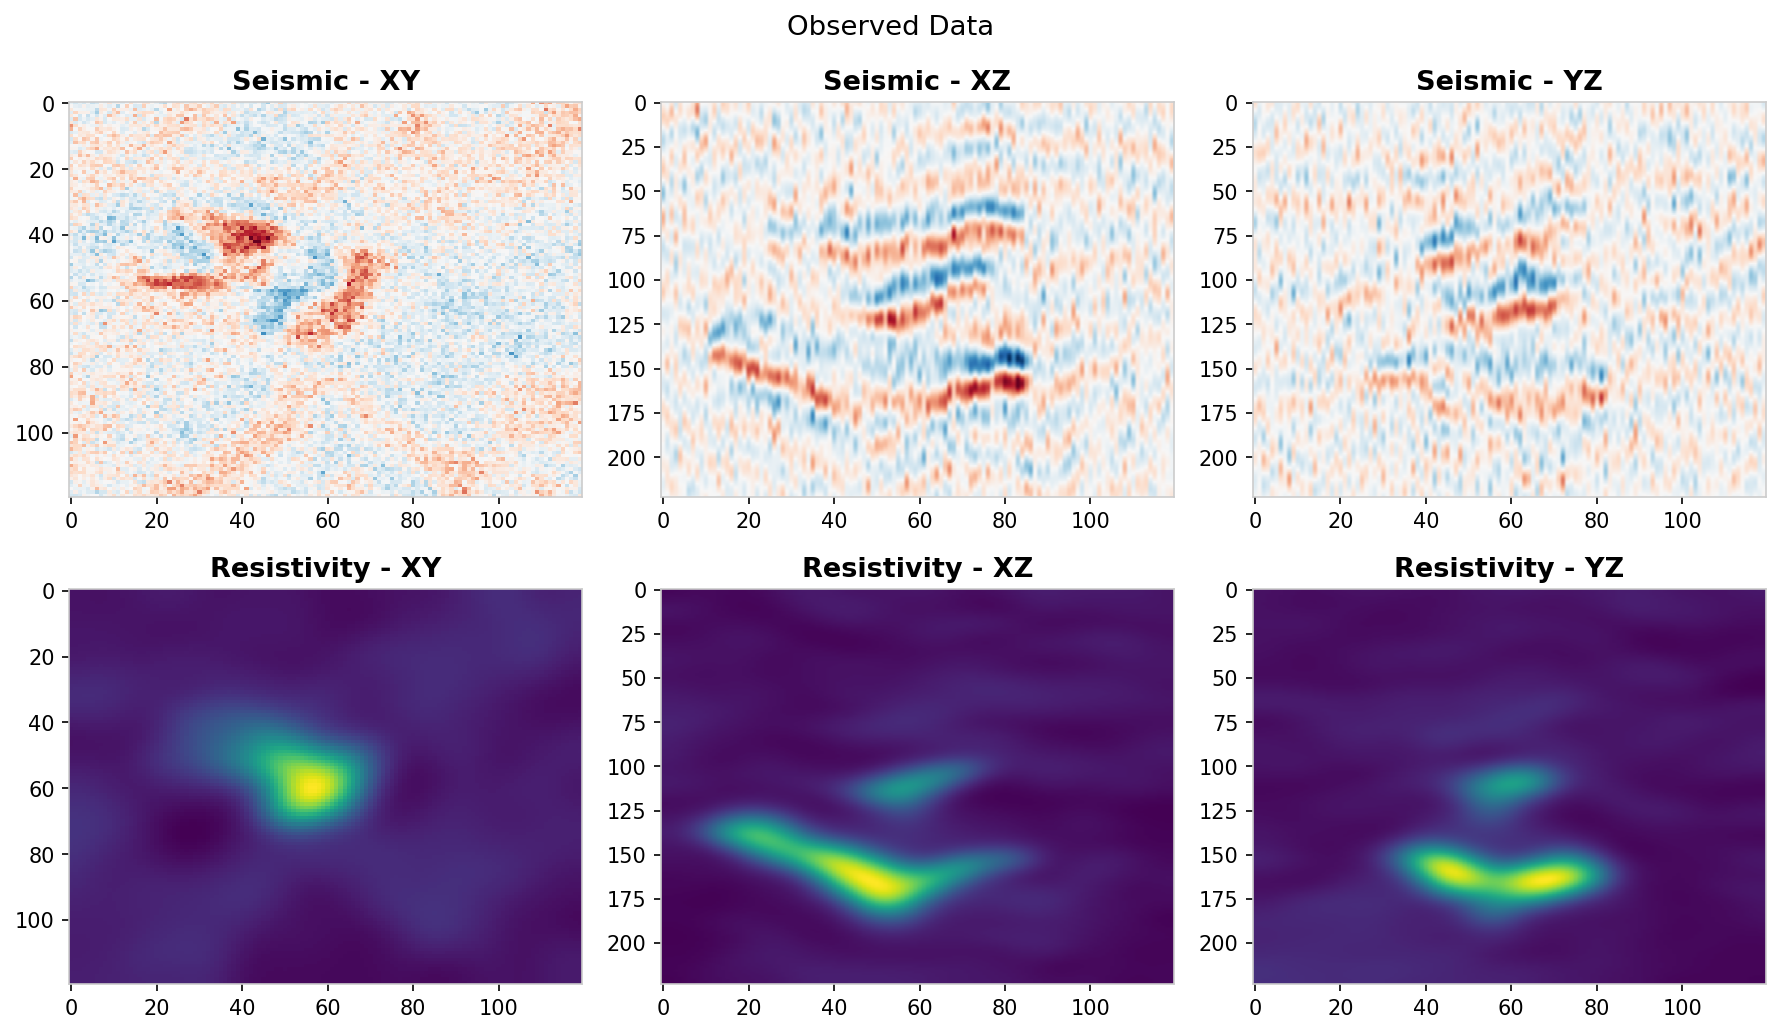

In [12]:
ix, iy, iz = NX // 2, NY // 2, NT // 2

# Observed data
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
seis_vmax = seis_true[0].abs().max().item() * 0.9

for i, (d, t) in enumerate([
    (seis_true[0, :, :, iz].T, "XY"),
    (seis_true[0, :, iy, :].T, "XZ"),
    (seis_true[0, ix, :, :].T, "YZ"),
]):
    axes[0, i].imshow(d.cpu(), cmap="RdBu_r", vmin=-seis_vmax, vmax=seis_vmax, aspect="auto")
    axes[0, i].set_title(f"Seismic - {t}")

for i, (d, t) in enumerate([
    (res_true[:, :, iz].T, "XY"),
    (res_true[:, iy, :].T, "XZ"),
    (res_true[ix, :, :].T, "YZ"),
]):
    axes[1, i].imshow(d.cpu(), cmap="viridis", aspect="auto")
    axes[1, i].set_title(f"Resistivity - {t}")

plt.suptitle("Observed Data")
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '15_observed_data.png'))
plt.show()

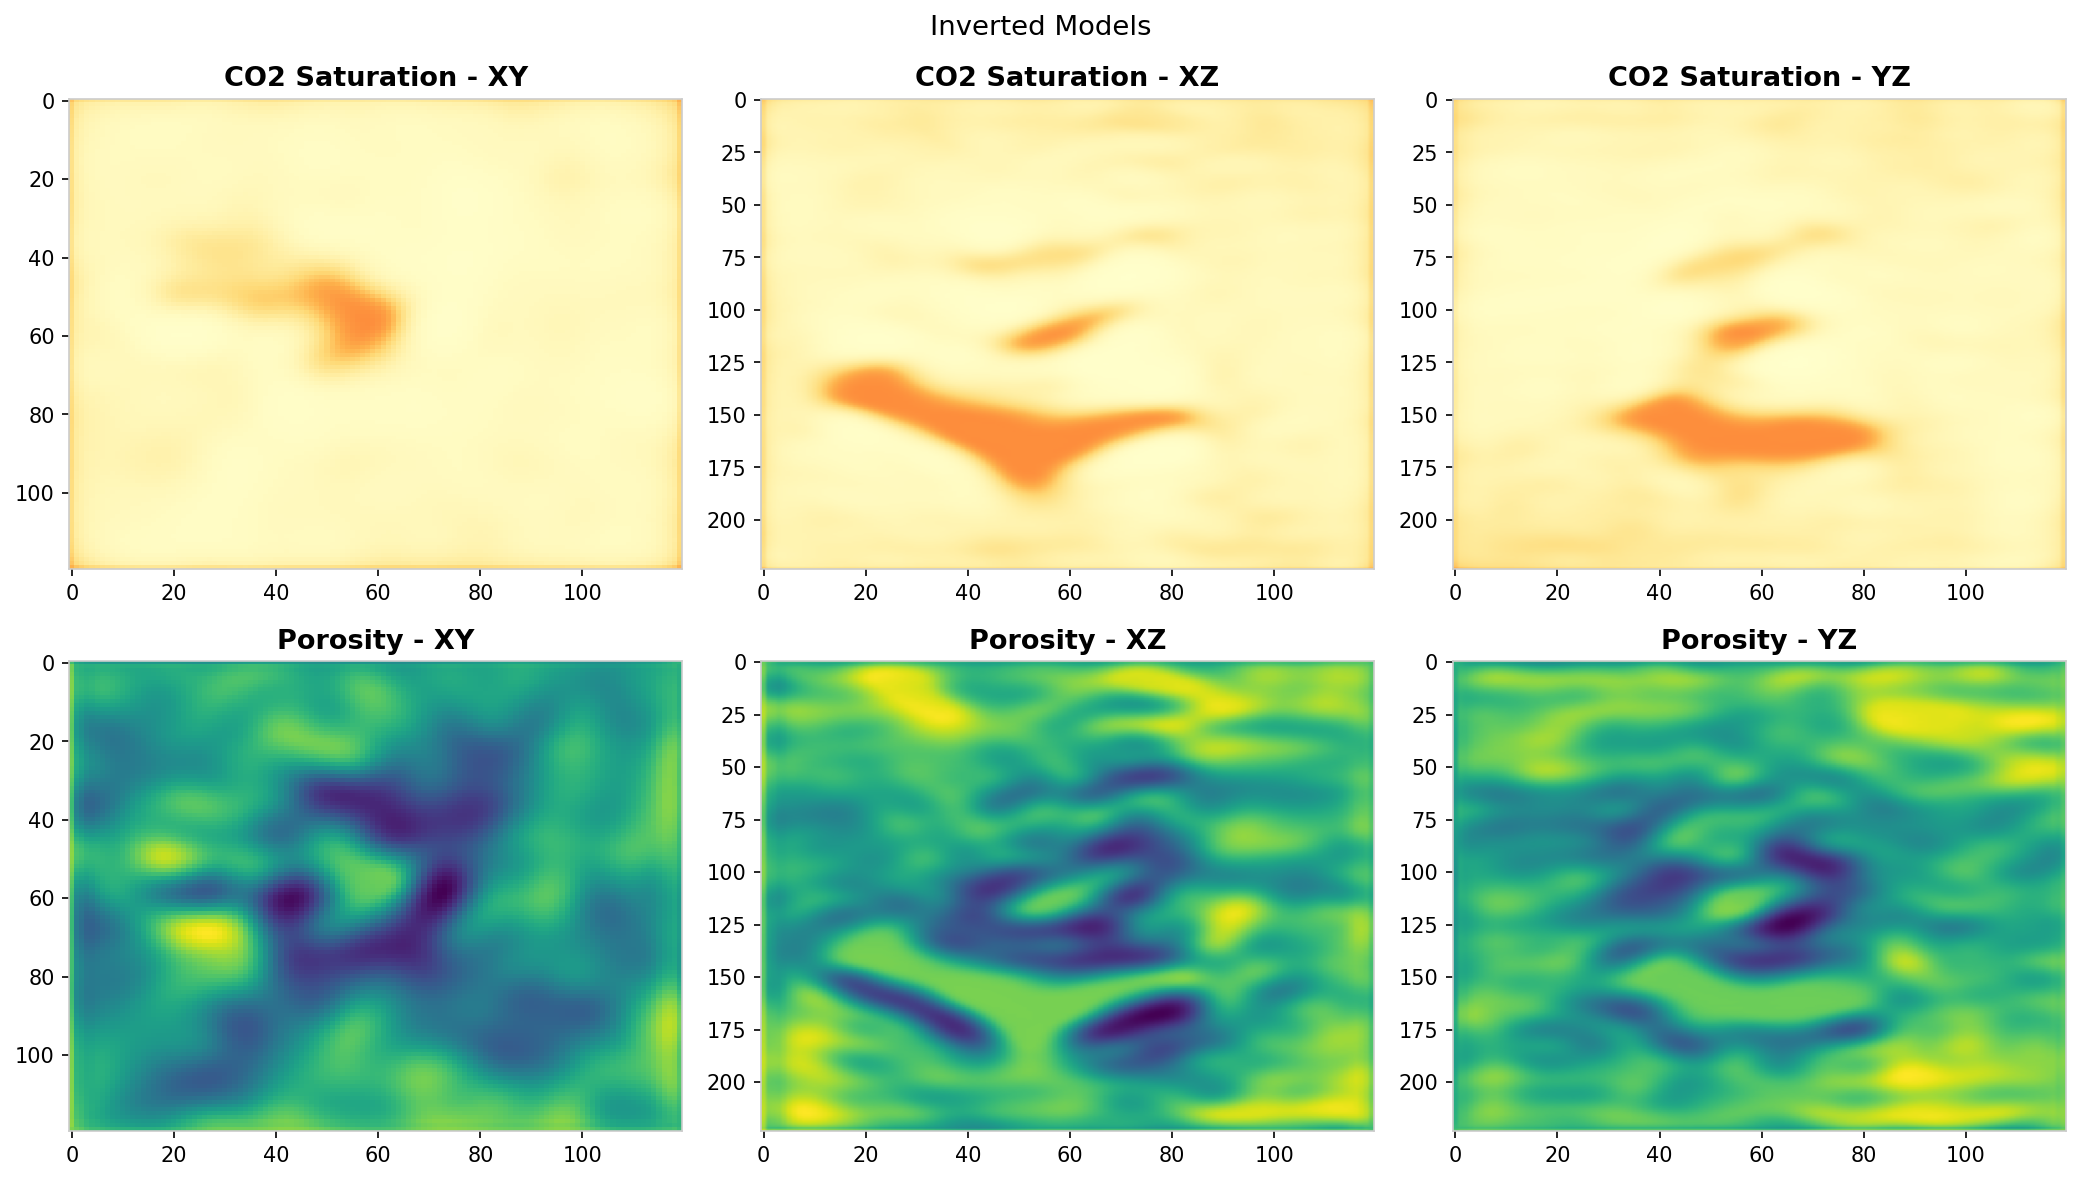

In [13]:
# Inverted models
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, (d, t) in enumerate([
    (sat_inv[:, :, iz].T, "XY"),
    (sat_inv[:, iy, :].T, "XZ"),
    (sat_inv[ix, :, :].T, "YZ"),
]):
    axes[0, i].imshow(d.cpu(), cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
    axes[0, i].set_title(f"CO2 Saturation - {t}")

for i, (d, t) in enumerate([
    (poro_inv[:, :, iz].T, "XY"),
    (poro_inv[:, iy, :].T, "XZ"),
    (poro_inv[ix, :, :].T, "YZ"),
]):
    axes[1, i].imshow(d.cpu(), cmap="viridis", aspect="auto")
    axes[1, i].set_title(f"Porosity - {t}")

plt.suptitle("Inverted Models")
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '15_inverted_models.png'))
plt.show()

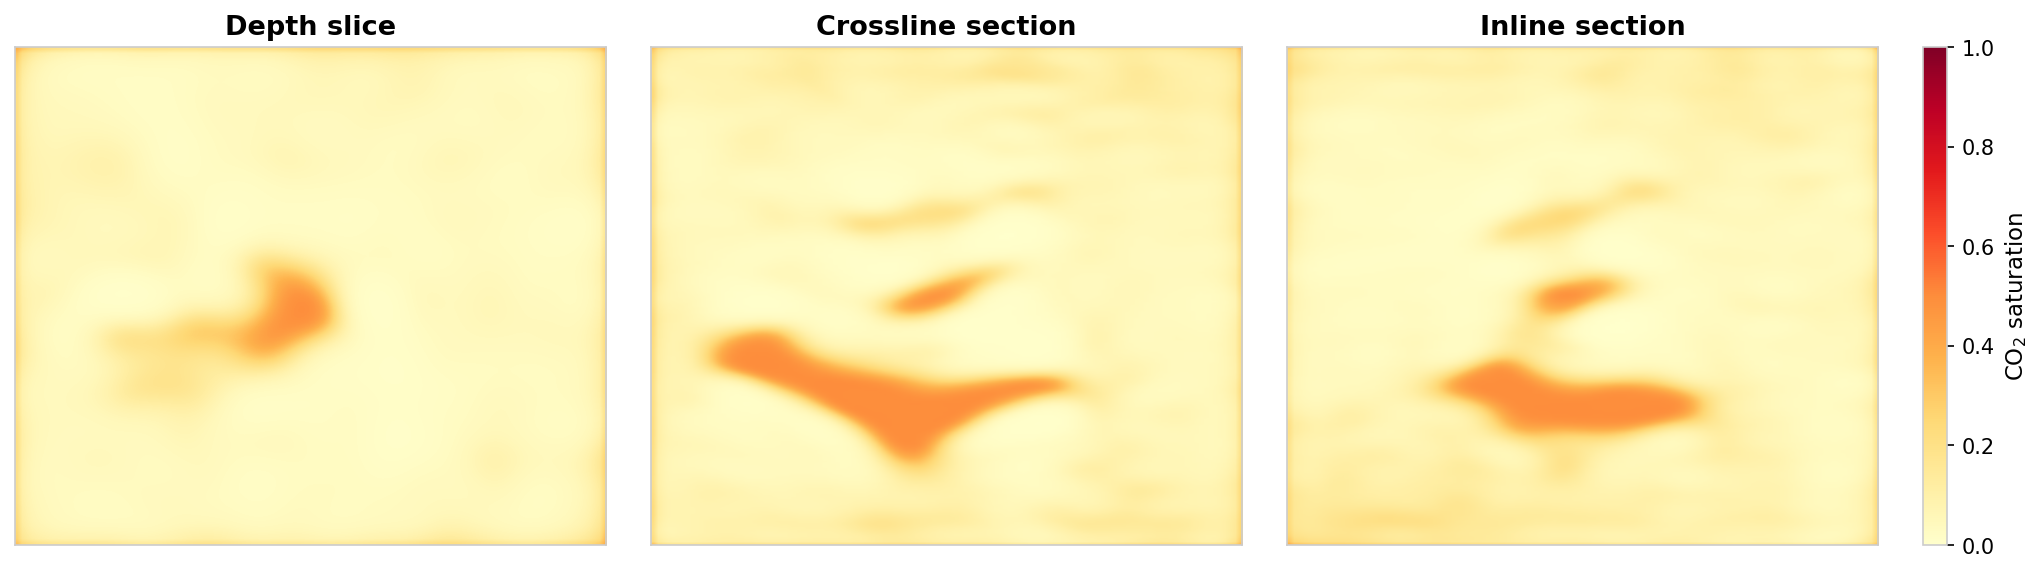

In [14]:
# CO2 saturation slices
sat_np = sat_inv.detach().cpu().numpy()

slice_labels = ["Depth slice", "Crossline section", "Inline section"]
slices = [sat_np[:, :, iz].T, sat_np[:, iy, :].T, sat_np[ix, :, :].T]

fig = plt.figure(figsize=(14, 4))
gs = gridspec.GridSpec(
    1, 4,
    width_ratios=[1, 1, 1, 0.04],
    wspace=0.10,
    left=0.03, right=0.95, bottom=0.05, top=0.88,
)

im = None
for c, (img, label) in enumerate(zip(slices, slice_labels)):
    ax = fig.add_subplot(gs[0, c])
    im = ax.imshow(img, origin="lower", vmin=0, vmax=1,
                   aspect="auto", cmap="YlOrRd", interpolation="bilinear")
    if c >= 1:
        ax.invert_yaxis()
    ax.set_title(label, pad=6)
    ax.set_xticks([])
    ax.set_yticks([])

cax = fig.add_subplot(gs[0, 3])
cb = fig.colorbar(im, cax=cax)
cb.set_label("CO$_2$ saturation")

plt.savefig(os.path.join(FIGS_DIR, "15_figure4.png"))
plt.show()

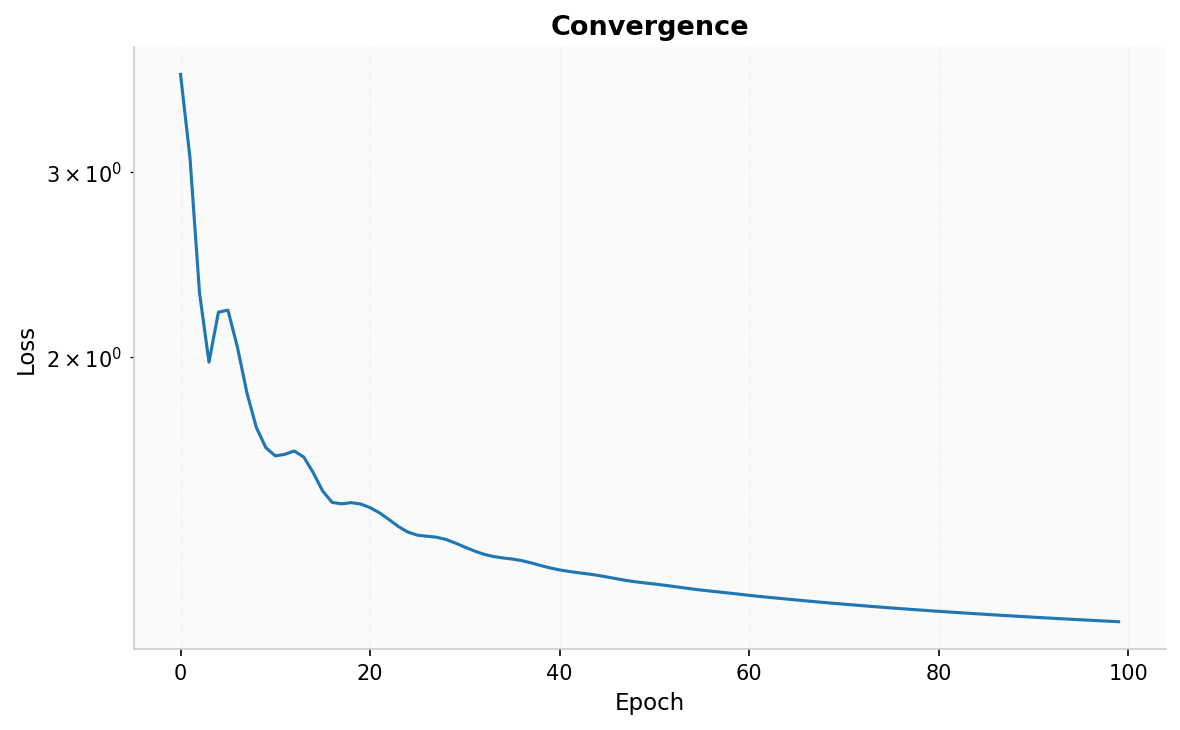

Joint Inversion Complete!


In [15]:
# Convergence
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(result.loss_history, color='#1f77b4', lw=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Convergence")
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '15_convergence.png'))
plt.show()

print("Joint Inversion Complete!")